Step 1: Import necessary libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import ssl

Step 2: Load image from Google Drive

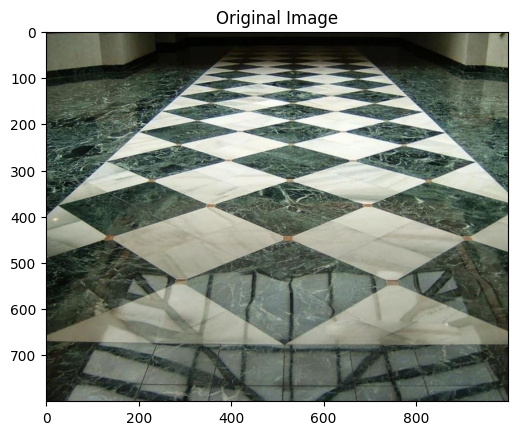

In [2]:
image_url = "https://drive.google.com/uc?export=download&id=1F700v7EPQIdbXz0k87-tRVueC4ZZXxGu"
context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('on')
plt.show()

Step 3: Define Parallel Line Pairs

    We need 2 pairs of lines which are parallel in real world, but intersect (vanish) in projective space

        Format: [x, y] points of line segments in image (manually selected for this image)
        Line l1 and l2 are parallel (e.g., horizontal tiles)
        Line l3 and l4 are parallel (e.g., vertical tiles)

        Parallel line pairs in real world but appear to converge in image
        Horizontal tile lines (example points, update if needed)

In [3]:
p1, p2 = np.array([130, 210]), np.array([300, 180])
p3, p4 = np.array([110, 70]),  np.array([270, 60])

# Vertical tile lines
p5, p6 = np.array([130, 210]), np.array([110, 70])
p7, p8 = np.array([300, 180]), np.array([270, 60])

Step 4: Line Equation via Cross Product

In [4]:
def get_line(p1, p2):
    """Compute homogeneous line: ax + by + c = 0 from 2 points."""
    return np.cross(np.append(p1, 1), np.append(p2, 1))

l1 = get_line(p1, p2)
l2 = get_line(p3, p4)
l3 = get_line(p5, p6)
l4 = get_line(p7, p8)

Step 5: Vanishing Points (where parallel lines meet)

    Vanishing point = intersection of parallel lines: v = l1 x l2

        # Affine rectification matrix H_affine:
            H_affine = [[1, 0, 0],
                        [0, 1, 0],
                        [l1, l2, l3]]  <- last row is l_inf


In [5]:
# v = l1 × l2, normalized
v1 = np.cross(l1, l2)
v1 = v1 / v1[2]

v2 = np.cross(l3, l4)
v2 = v2 / v2[2]

# --------------------------
# Step 5: Vanishing Line (line at infinity)
# --------------------------
# l_inf = v1 × v2
l_inf = np.cross(v1, v2)
l_inf = l_inf / l_inf[2]

# --------------------------
# Step 6: Affine Homography Matrix
# --------------------------
# H_affine maps vanishing line to line at infinity
H_affine = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [l_inf[0], l_inf[1], l_inf[2]]
])

Step 7: Apply Homography

In [6]:
height, width = img.shape[:2]
affine_rectified = cv2.warpPerspective(img, H_affine, (width, height))

Step 8: Show Result

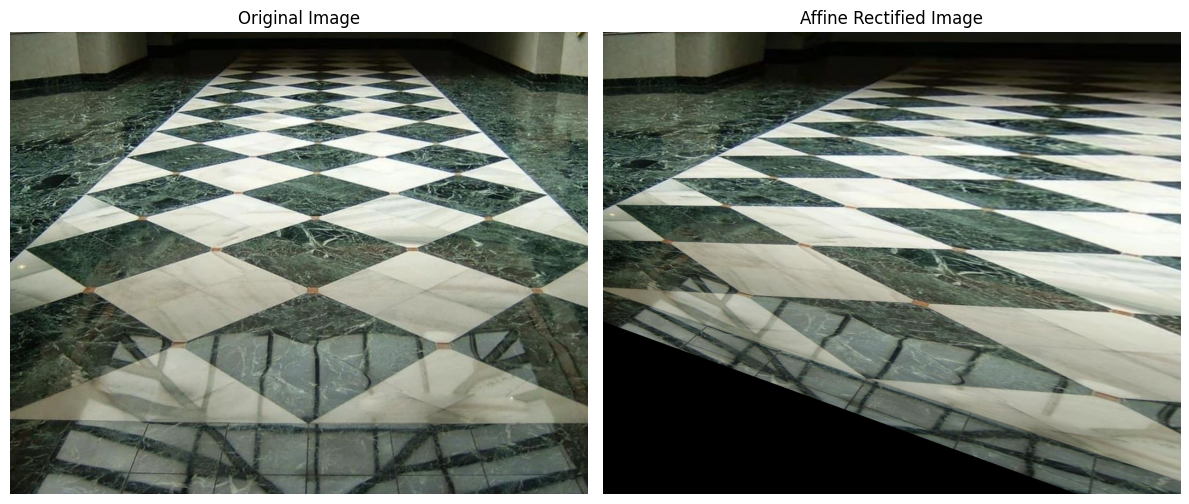

In [7]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(affine_rectified, cv2.COLOR_BGR2RGB))
plt.title("Affine Rectified Image")
plt.axis('off')
plt.tight_layout()
plt.show()